# Data Science & ML Job Salaries – EDA

**Fragestellung:** Was bestimmt das Gehalt als Data Scientist oder Machine Learning Engineer?

**Datensatz:** [Data Science Salaries 2024 – Kaggle](https://www.kaggle.com/datasets/sazidthe1/data-science-salaries)  
**Quelle:** ai-jobs.net | Zeitraum: 2020–2024

## 1. Setup & Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot-Stil
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

print(f"pandas: {pd.__version__}")

pandas: 3.0.2


## 2. Daten laden & ersten Überblick verschaffen

In [3]:
# Load dataset
df_raw = pd.read_csv("../data/raw/data_science_salaries.csv")
df = df_raw.copy()

# dimension 
print(df_raw.shape)
print(df_raw.size)

(6599, 11)
72589


In [4]:
# structure
#print(df_raw.head(3))
#print(df_raw.tail(3))
df_raw.sample(10)



,job_title,experience_level,employment_type,work_models,work_year,employee_residence,salary,salary_currency,salary_in_usd,company_location,company_size
2048,Data Engineer,Senior-level,Full-time,Remote,2023,United States,135000,USD,135000,United States,Medium
2988,Data Modeler,Senior-level,Full-time,On-site,2023,United States,147100,USD,147100,United States,Medium
3564,Business Intelligence Engineer,Senior-level,Full-time,On-site,2023,United States,210000,USD,210000,United States,Medium
3596,BI Analyst,Senior-level,Full-time,Remote,2023,United States,150000,USD,150000,United States,Medium
4326,Machine Learning Engineer,Mid-level,Full-time,Remote,2023,United States,110000,USD,110000,United States,Large
4691,Machine Learning Scientist,Senior-level,Full-time,On-site,2023,United Kingdom,171000,GBP,210398,United Kingdom,Medium
5902,Data Analyst,Senior-level,Full-time,On-site,2022,United States,81666,USD,81666,United States,Medium
4975,AI Developer,Entry-level,Full-time,On-site,2023,Germany,60000,EUR,64781,Germany,Medium
3834,Cloud Data Engineer,Entry-level,Full-time,Hybrid,2023,Germany,100000,USD,100000,United States,Large
974,Data Scientist,Senior-level,Full-time,On-site,2023,United States,93300,USD,93300,United States,Medium


In [5]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 6599 entries, 0 to 6598
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   job_title           6599 non-null   str  
 1   experience_level    6599 non-null   str  
 2   employment_type     6599 non-null   str  
 3   work_models         6599 non-null   str  
 4   work_year           6599 non-null   int64
 5   employee_residence  6599 non-null   str  
 6   salary              6599 non-null   int64
 7   salary_currency     6599 non-null   str  
 8   salary_in_usd       6599 non-null   int64
 9   company_location    6599 non-null   str  
 10  company_size        6599 non-null   str  
dtypes: int64(3), str(8)
memory usage: 567.2 KB


In [6]:
df_raw.describe()

,work_year,salary,salary_in_usd
count,6599.000000,6.599000e+03,6599.000000
mean,2022.818457,1.792833e+05,145560.558569
std,0.674809,5.263722e+05,70946.838070
min,2020.000000,1.400000e+04,15000.000000
25%,2023.000000,9.600000e+04,95000.000000
50%,2023.000000,1.400000e+05,138666.000000
75%,2023.000000,1.875000e+05,185000.000000
max,2024.000000,3.040000e+07,750000.000000


In [7]:
# Missing Values
df_raw.isnull().sum()

job_title             0
experience_level      0
employment_type       0
work_models           0
work_year             0
employee_residence    0
salary                0
salary_currency       0
salary_in_usd         0
company_location      0
company_size          0
dtype: int64

## 3. Gehalts-Entwicklung über die Jahre (2020–2024)

In [8]:
salary_by_year = (df
                  .groupby("work_year")["salary_in_usd"]
                  .agg(mean = "mean", median = "median", count = "count")
                  .round({"mean" : 2, "median" : 2})
                  .reset_index())
salary_by_year


,work_year,mean,median,count
0,2020,102250.87,79833.0,75
1,2021,99501.29,82636.0,216
2,2022,131788.54,130000.0,1112
3,2023,150791.42,143000.0,4625
4,2024,153124.08,138000.0,571


### Beobachtung: Datenlage und Trendinterpretation

Die Jahre 2020 (n=75) und 2021 (n=216) sind im Datensatz stark unterrepräsentiert —
im Vergleich zu 2022 (n=1.112) und 2023 (n=4.625). Trendaussagen für diese frühen
Jahre sind daher mit Vorsicht zu interpretieren: Der Median basiert auf einer kleinen,
möglicherweise nicht repräsentativen Stichprobe.

Ab 2022 ist die Datenlage solide genug für belastbare Aussagen.

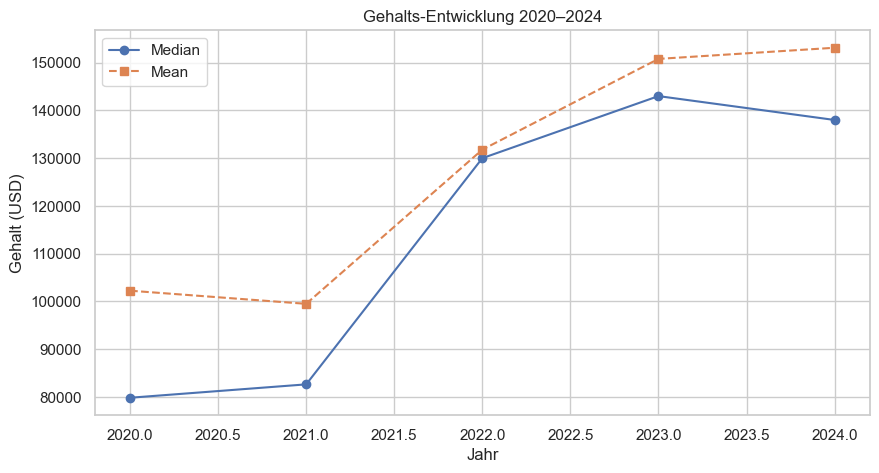

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(salary_by_year["work_year"], salary_by_year["median"], marker="o", label = "Median")
ax.plot(salary_by_year["work_year"], salary_by_year["mean"], marker="s", linestyle="--", label = "Mean")

ax.set_title("Gehalts-Entwicklung 2020–2024")
ax.set_xlabel("Jahr")
ax.set_ylabel("Gehalt (USD)")

ax.legend()

plt.show()

/var/folders/_d/4llk731n547f811mb_kz1m2h0000gn/T/ipykernel_9185/4126566816.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


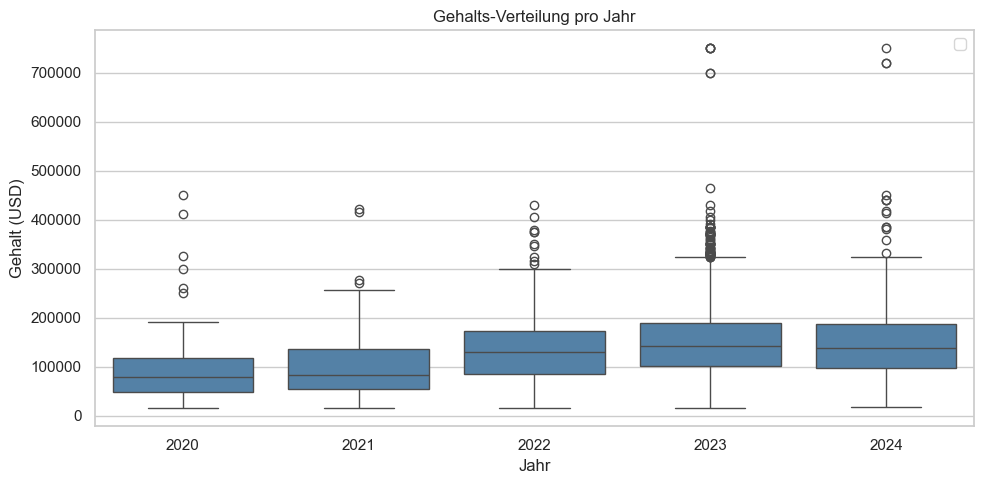

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(data=df, x="work_year", y="salary_in_usd", ax=ax, color="steelblue")

ax.set_title("Gehalts-Verteilung pro Jahr")
ax.set_xlabel("Jahr")
ax.set_ylabel("Gehalt (USD)")


plt.tight_layout()

plt.show()



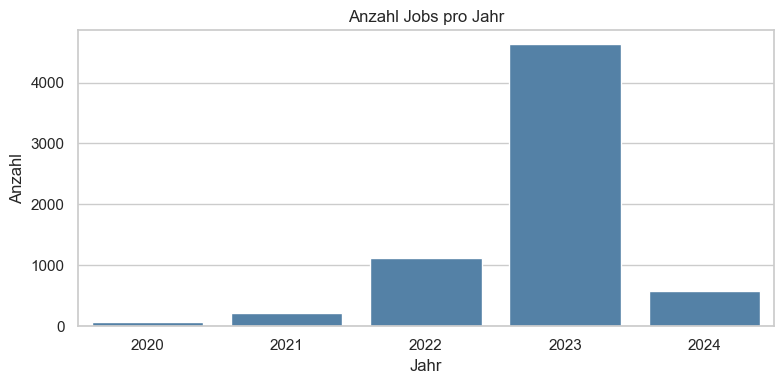

In [11]:
fig, ax = plt.subplots(figsize=(8,4))

sns.barplot(data=salary_by_year,x = "work_year", y = "count", ax=ax, color="steelblue")

ax.set_title("Anzahl Jobs pro Jahr")
ax.set_xlabel("Jahr")
ax.set_ylabel("Anzahl")
plt.tight_layout()
plt.show()

### Fazit: Gehalts-Entwicklung 2020–2024

| Jahr | Median (USD) | n     |
|------|--------------|-------|
| 2020 | 79.833       | 75    |
| 2021 | 82.636       | 216   |
| 2022 | 130.000      | 1.112 |
| 2023 | 143.000      | 4.625 |
| 2024 | 138.000      | 571   |

Der Median-Jahresverdienst stieg von 2020 bis 2023 um ~79% — von ~80k auf ~143k USD.
Der leichte Rückgang 2024 (~138k) ist mit Vorsicht zu interpretieren: n=571 erfasst
möglicherweise nur einen Teil des Jahres, da Einträge auf ai-jobs.net oft mit Verzögerung
gemeldet werden (Reporting-Lag).

Das starke Wachstum 2022–2023 korreliert mit dem KI/ML-Boom und der gestiegenen
Nachfrage nach Data-Science-Talenten in dieser Periode.

## 4. Einfluss des Erfahrungslevels (Junior → Senior → Executive)

In [12]:
salary_by_experience = (df
        .groupby("experience_level")["salary_in_usd"]
        .agg(mean = "mean", median = "median", count = "count")
        .round({"mean" : 2, "median" : 2})
        .reset_index()
        )
salary_by_experience

,experience_level,mean,median,count
0,Entry-level,84448.92,75000.0,565
1,Executive-level,189687.35,184560.0,254
2,Mid-level,119019.81,106500.0,1675
3,Senior-level,162071.06,153600.0,4105


### Beobachtung: Ungleiche Sample Sizes

Die Stichprobengrößen sind stark ungleich verteilt: Senior-level dominiert mit n=4.105,
gefolgt von Mid-level (n=1.675) und Entry-level (n=565). Executive-level ist mit n=254
deutlich schwächer vertreten — Gehaltsaussagen für diese Gruppe sind weniger stabil
und könnten durch einzelne Hochverdiener stärker verzerrt sein als bei den anderen Leveln.

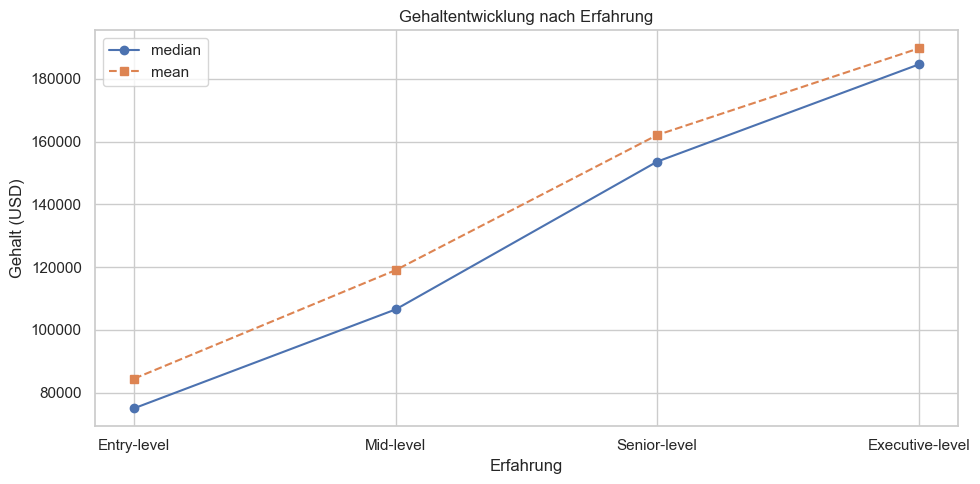

In [13]:
# Richtige Reihenfolge definieren
order = ["Entry-level", "Mid-level", "Senior-level", "Executive-level"]

# DataFrame in dieser Reihenfolge sortieren
salary_by_experience = salary_by_experience.set_index("experience_level").loc[order].reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(salary_by_experience["experience_level"], salary_by_experience["median"], label="median", marker="o")
ax.plot(salary_by_experience["experience_level"], salary_by_experience["mean"], label="mean", linestyle="--", marker="s")

ax.set_title("Gehaltentwicklung nach Erfahrung")
ax.set_xlabel("Erfahrung")
ax.set_ylabel("Gehalt (USD)")

ax.legend()
plt.tight_layout()
plt.show()

/var/folders/_d/4llk731n547f811mb_kz1m2h0000gn/T/ipykernel_9185/2120373248.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


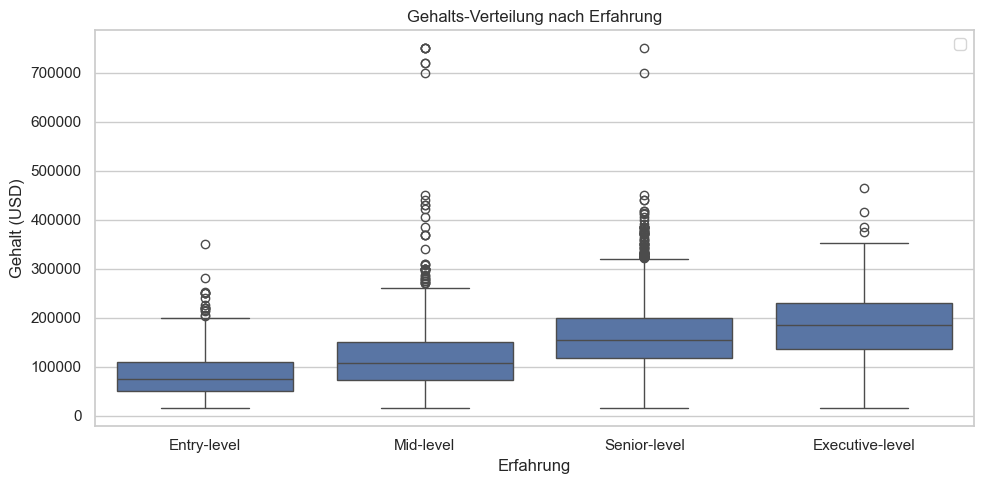

In [14]:
fig, ax = plt.subplots(figsize = (10,5))

sns.boxplot(data=df, x="experience_level",y="salary_in_usd",order=["Entry-level", "Mid-level", "Senior-level", "Executive-level"])

ax.set_title("Gehalts-Verteilung nach Erfahrung")
ax.set_xlabel("Erfahrung")
ax.set_ylabel("Gehalt (USD)")


plt.tight_layout()

plt.show()

### Fazit: Erfahrung als stärkster Gehaltstreiber

| Erfahrungslevel  | Median (USD) | n     |
|------------------|--------------|-------|
| Entry-level      | 75.000       | 565   |
| Mid-level        | 106.500      | 1.675 |
| Senior-level     | 153.600      | 4.105 |
| Executive-level  | 184.560      | 254   |

Der Sprung von Entry- zu Senior-level beträgt ~105% — Erfahrung verdoppelt das Gehalt
nahezu. Der weitere Schritt zu Executive (~20%) ist moderater, unterschätzt aber
vermutlich den tatsächlichen Unterschied: Executive-Vergütungen beinhalten häufig
Boni und Equity-Komponenten, die in diesem Datensatz nicht erfasst sind.

Erfahrungslevel ist damit der stärkste einzelne Gehaltstreiber im gesamten Datensatz.

## 5. Top & Bottom Job-Titel nach Gehalt

### Methodische Entscheidung: Minimum-Threshold für Job-Titel

Nicht alle 132 Job-Titel im Datensatz eignen sich für einen stabilen Gehaltsvergleich.
Die Verteilung der Einträge pro Job-Titel ist stark rechtsschief: Titel wie *Data Scientist*
(n=1.243) oder *Data Engineer* (n=1.307) dominieren, während mehr als die Hälfte aller
Titel weniger als 6 Einträge aufweist (Median der Häufigkeiten = 6).

Ein Median aus wenigen Datenpunkten ist statistisch nicht stabil — Ausreißer einzelner
Gehaltsmeldungen würden das Ergebnis zufällig verzerren.

**Entscheidung:** Nur Job-Titel mit mindestens **30 Einträgen** werden in die Analyse
einbezogen. Diese Faustformel basiert auf dem Central Limit Theorem: Ab ~30 Beobachtungen
nähert sich die Stichprobenverteilung einer Normalverteilung an, was statistische Aussagen
deutlich stabiler macht.

**Limitation:** Mögliche Label-Inkonsistenzen (z.B. *BI Analyst* vs.
*Business Intelligence Analyst*) wurden nicht bereinigt, da eine inhaltliche Gleichsetzung
nicht mit Sicherheit belegt werden kann. Die tatsächliche Sample Size vergleichbarer Rollen
könnte in Einzelfällen höher liegen.

In [15]:

job_title_counts = df["job_title"].value_counts()
job_title_median = job_title_counts.median()  # = 6.0 — zu niedrig, siehe Markdown oben


job_title_counts_filtered = job_title_counts[job_title_counts >= 30]

job_title_counts_filtered


job_title
Data Engineer                               1307
Data Scientist                              1243
Data Analyst                                 910
Machine Learning Engineer                    629
Analytics Engineer                           246
Research Scientist                           206
Data Architect                               176
Research Engineer                            136
ML Engineer                                  113
Applied Scientist                             97
Data Science Manager                          86
Business Intelligence Analyst                 82
Machine Learning Scientist                    73
Business Intelligence Engineer                69
Data Manager                                  63
Research Analyst                              60
Data Science                                  56
AI Engineer                                   48
Data Specialist                               47
Data Science Consultant                       42
BI Develop

### Beobachtung: Extreme Gehaltsspannen bei ML/AI-Rollen

Der Vergleich von Min-, Max- und Median-Gehalt zeigt bei mehreren Job-Titeln 
extreme Spannen. Besonders auffällig: *Machine Learning Engineer*, 
*Machine Learning Scientist* und *Research Scientist* weisen Max-Werte von 
bis zu 750.000 USD auf — bei Median-Werten zwischen 165k und 190k USD.

**Mögliche Erklärungen:**
- **Top-Tech-Firmen** (z.B. Google, Meta, OpenAI) zahlen für Senior-Positionen 
  tatsächlich außergewöhnlich hohe Gesamtvergütungen (Base + Bonus + Equity)
- **Falsch eingetragene Werte:** Da der Datensatz auf freiwilliger Selbstangabe 
  basiert (ai-jobs.net), sind Eingabefehler nicht auszuschließen

**Wichtig:** Mehrere Einträge zeigen Max-Werte im 700k–750k-Bereich — es handelt 
sich also nicht um einen einzelnen Ausreißer. Eine pauschale Bereinigung wäre 
daher nicht gerechtfertigt, da zumindest ein Teil dieser Werte plausibel sein 
könnte.

**Konsequenz für die Analyse:** Der Median bleibt die robuste Kennzahl für den 
Gehaltsvergleich — er wird durch solche Extremwerte nicht verzerrt.

**Weitere Datenqualitäts-Beobachtung:** Im gefilterten Ranking tauchen mutmaßlich 
synonyme Job-Titel separat auf — z.B. *ML Engineer* (n=113) und 
*Machine Learning Engineer* (n=629), sowie *Data Science* (n=56) und 
*Data Scientist* (n=1.243). Eine Zusammenführung dieser Titel wurde bewusst 
vermieden, da nicht mit Sicherheit belegt werden kann, dass sie in allen 
Unternehmen identische Rollen beschreiben. Eine Bereinigung würde eine Annahme 
in die Daten einbringen, die nicht aus dem Datensatz selbst ableitbar ist.

In [16]:
df_filtered = df[df["job_title"].isin(job_title_counts_filtered.index.to_list())]

df_job_title_grouped = (df_filtered.groupby("job_title").agg(
    count = ("job_title", "count"),
    min_salary = ("salary_in_usd", "min"),
    max_salary = ("salary_in_usd", "max"),
    median_salary = ("salary_in_usd", "median")
)).sort_values(by="median_salary", ascending=False).reset_index()

df_job_title_grouped

,job_title,count,min_salary,max_salary,median_salary
0,Director of Data Science,31,57786,375500,203016.0
1,Applied Scientist,97,20000,414000,191475.0
2,ML Engineer,113,15966,385000,189400.0
3,Data Science Manager,86,38915,328000,175000.0
4,Machine Learning Engineer,629,20000,750000,170730.0
5,Machine Learning Scientist,73,22800,750000,170000.0
6,Research Engineer,136,16455,720000,167250.0
7,Machine Learning Infrastructure Engineer,31,50180,260000,165400.0
8,Research Scientist,206,23000,720000,165250.0
9,AI Engineer,48,21593,372000,163000.0


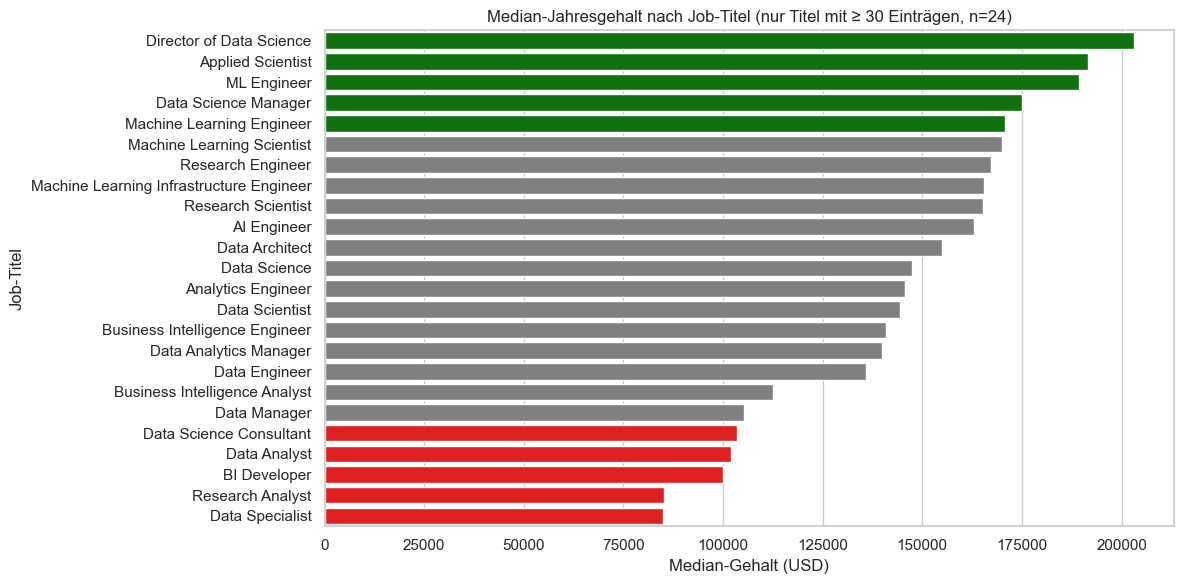

In [17]:
fig, ax = plt.subplots(figsize=(12,6))

colors = ["grey"] * 24
colors[:5] = ["green"] * 5
colors[-5:] = ["red"] * 5

sns.barplot(data=df_job_title_grouped,x = "median_salary", y = "job_title", ax=ax, palette=colors, hue="job_title", legend=False)

ax.set_title("Median-Jahresgehalt nach Job-Titel (nur Titel mit ≥ 30 Einträgen, n=24)")
ax.set_xlabel("Median-Gehalt (USD)")
ax.set_ylabel("Job-Titel")
plt.tight_layout()
plt.show()

## 6. Remote-Arbeit: zahlt sich das aus?

In [18]:
df["work_models"].value_counts() # absolute Häufigkeiten

work_models
On-site    3813
Remote     2561
Hybrid      225
Name: count, dtype: int64

In [19]:
df_work_models = (df.groupby("work_models").agg(
    count = ("work_models","count"),
    median_salary = ("salary_in_usd","median"),
    min_salary = ("salary_in_usd","min"),
    max_salary = ("salary_in_usd","max")
    )).sort_values(by="median_salary",ascending=False)
df_work_models

,count,median_salary,min_salary,max_salary
work_models,,,,
On-site,3813,142200.0,15000,750000
Remote,2561,136000.0,15000,700000
Hybrid,225,66192.0,15680,423000


### Beobachtung: Ausreißer und methodische Entscheidung

Die Verteilung der Work Models zeigt: On-site (~58%), Remote (~39%), 
Hybrid (~3%). Das entspricht dem erwarteten Bild — nach dem Post-COVID-Rückgang 
von Remote-Arbeit dominiert On-site wieder, Remote bleibt aber gerade im 
Tech-Bereich stark vertreten. Hybrid macht nur einen marginalen Anteil aus.

Ein erster Gehaltsvergleich (gruppiert nach Work Model: Median, Min, Max) zeigt 
starke Ausreißer in beide Richtungen. Das Minimum von 15.000 USD tritt in allen 
Gruppen auf. Eine naheliegende Hypothese: Teilzeit- oder Praktikumsstellen 
könnten die unteren Werte verzerren — diese Hypothese wird im nächsten Schritt überprüft.

**Methodische Entscheidung:** Um einen fairen Vergleich zu gewährleisten, wird die 
Analyse auf `Full-time`-Stellen beschränkt. Diese machen 99.3% des Datensatzes aus 
(n=6.552). Die übrigen Employment Types (Contract n=19, Part-time n=16, Freelance n=12) 
sind statistisch nicht belastbar und werden ausgeschlossen.

In [20]:
df['employment_type'].value_counts()

employment_type
Full-time    6552
Contract       19
Part-time      16
Freelance      12
Name: count, dtype: int64

In [21]:
df_ft = df[df['employment_type'] == 'Full-time'] # filtere nach full-time Stellen

df_ft_grouped = (df_ft.groupby("work_models").agg(
        count = ("work_models","count"),
        median_salary = ("salary_in_usd","median"),
        min_salary = ("salary_in_usd","min"),
        max_salary = ("salary_in_usd","max")
    )).sort_values(by="median_salary",ascending=False)
df_ft_grouped

,count,median_salary,min_salary,max_salary
work_models,,,,
On-site,3808,142200.0,15000,750000
Remote,2531,136850.0,15000,700000
Hybrid,213,69133.0,15680,423000


### Methodische Einschränkung: Geografische Verzerrung

Die Filterung auf Full-time-Stellen entfernt zwar den Einfluss des Employment Types,
löst aber ein zweites Problem nicht: geografische Gehaltsunterschiede.
Ein Full-time Data Scientist in Indien oder Osteuropa verdient strukturell deutlich
weniger als ein vergleichbarer Job in den USA — unabhängig vom Work Model.

Das Minimum-Gehalt von 15.000 USD bleibt auch nach der Filterung bestehen und ist
höchstwahrscheinlich auf solche geografischen Unterschiede zurückzuführen, nicht auf
das Work Model selbst.

Eine vollständige Bereinigung würde eine zusätzliche Filterung nach Region erfordern.
Da geografische Unterschiede in **Abschnitt 7** separat analysiert werden,
wird hier bewusst darauf verzichtet — die folgenden Visualisierungen sollten
daher mit dieser Einschränkung im Hinterkopf gelesen werden.

/var/folders/_d/4llk731n547f811mb_kz1m2h0000gn/T/ipykernel_9185/127685732.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


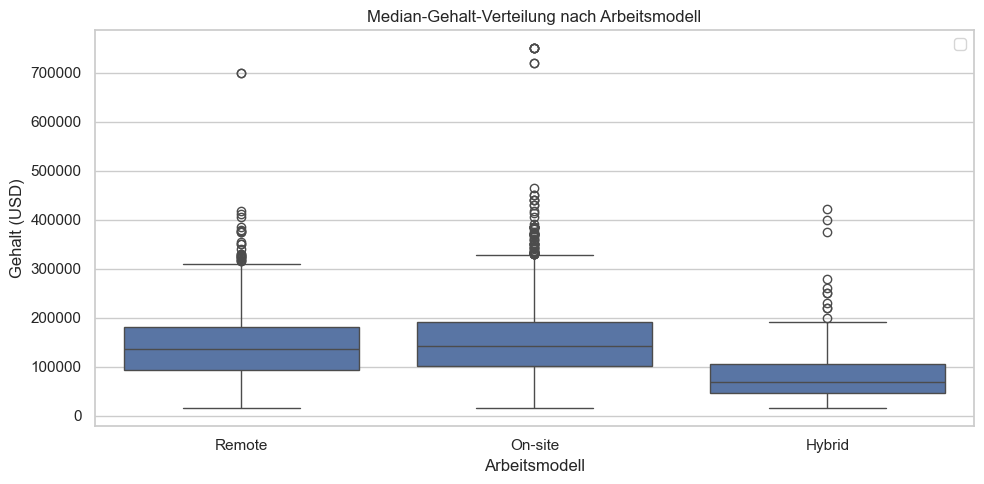

In [22]:
fig, ax = plt.subplots(figsize = (10,5))

sns.boxplot(data=df_ft, x="work_models",y="salary_in_usd")

ax.set_title("Median-Gehalt-Verteilung nach Arbeitsmodell")
ax.set_xlabel("Arbeitsmodell")
ax.set_ylabel("Gehalt (USD)")


plt.tight_layout()

plt.show()

/var/folders/_d/4llk731n547f811mb_kz1m2h0000gn/T/ipykernel_9185/836918650.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


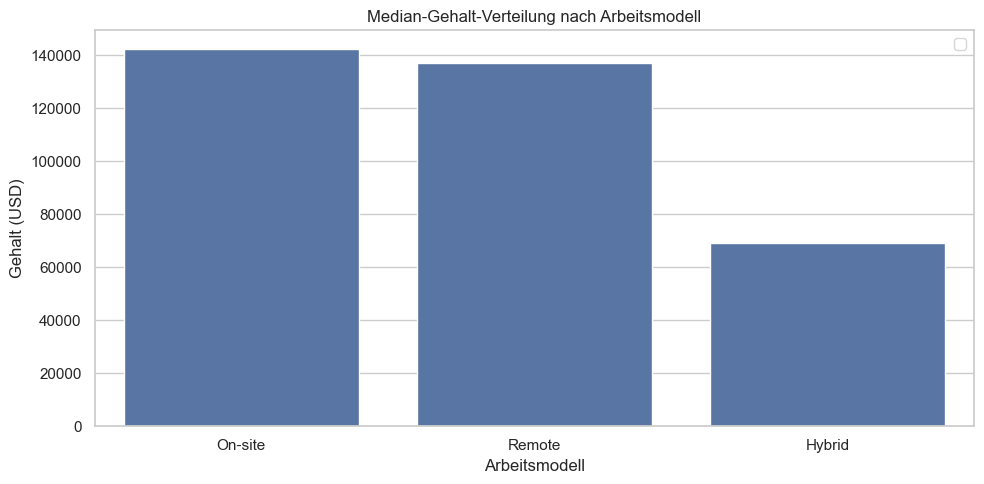

In [23]:
fig, ax = plt.subplots(figsize = (10,5))

sns.barplot(data=df_ft_grouped, x="work_models",y="median_salary")

ax.set_title("Median-Jahresgehalt nach Arbeitsmodell")
ax.set_xlabel("Arbeitsmodell")
ax.set_ylabel("Gehalt (USD)")


plt.tight_layout()

plt.show()

### Fazit: Zahlt sich Remote-Arbeit aus?

Auf Basis der Full-time-gefilterten Daten zeigt sich:

| Work Model | Median-Gehalt | n     |
|------------|---------------|-------|
| On-site    | 142.200 USD   | 3.808 |
| Remote     | 136.850 USD   | 2.531 |
| Hybrid     | 69.133 USD    | 213   |

Der Unterschied zwischen On-site und Remote beträgt ~5.350 USD (~3,8%) —
das ist kein signifikanter Unterschied. Remote-Arbeit zahlt sich finanziell
also weder deutlich aus noch benachteiligt sie.

Der niedrige Hybrid-Median ist mit Vorsicht zu interpretieren: n=213 ist
im Vergleich zu den anderen Gruppen sehr klein, was die Aussagekraft einschränkt.
Zudem greift hier dieselbe geografische Verzerrung wie oben beschrieben.

## 7. Geografische Unterschiede: USA vs. Europa vs. Rest

In [24]:
# Regionen definieren
europe = [
    'United Kingdom', 'Germany', 'Spain', 'France', 'Portugal', 'Netherlands',
    'Italy', 'Greece', 'Ireland', 'Poland', 'Estonia', 'Sweden', 'Denmark',
    'Norway', 'Finland', 'Belgium', 'Austria', 'Switzerland', 'Romania',
    'Czech Republic', 'Hungary', 'Bulgaria', 'Croatia', 'Lithuania', 'Latvia',
    'Slovakia', 'Slovenia', 'Luxembourg', 'Malta', 'Cyprus'
]

def assign_region(country):
    if country == 'United States':
        return 'USA'
    elif country in europe:
        return 'Europa'
    else:
        return 'Rest der Welt'

df['region'] = df['company_location'].apply(assign_region)

salary_by_region = (df
    .groupby('region')['salary_in_usd']
    .agg(count='count', median='median', mean='mean')
    .round({'median': 0, 'mean': 0})
    .sort_values('median', ascending=False)
    .reset_index()
)
salary_by_region

,region,count,median,mean
0,USA,5354,148250.0,157073.0
1,Rest der Welt,485,95000.0,107441.0
2,Europa,760,73840.0,88784.0


### Beobachtung: US-Markt dominiert – strukturell und numerisch

~80% aller Datenpunkte stammen aus den USA (n=5.354), was Gesamtdurchschnitte stark verzerrt.
Europa ist mit n=760 (~12%) vertreten, der Rest der Welt mit n=485 (~8%).
Die geografische Dominanz der USA ist kein Zufall: ai-jobs.net ist eine englischsprachige Plattform,
auf der US-Arbeitnehmer überproportional vertreten sind (Self-Reporting Bias).
Gehaltsvergleiche zwischen Regionen können echte Marktunterschiede widerspiegeln –
sind aber auch durch unterschiedliche Kaufkraft, Besteuerung und Lebenshaltungskosten beeinflusst.

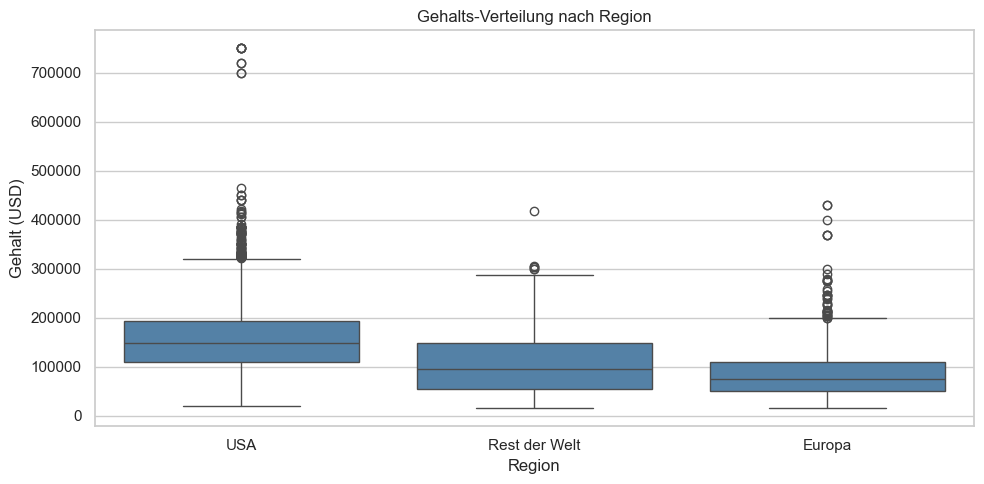

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))

region_order = ['USA', 'Rest der Welt', 'Europa']

sns.boxplot(data=df, x='region', y='salary_in_usd', order=region_order, ax=ax, color='steelblue')

ax.set_title('Gehalts-Verteilung nach Region')
ax.set_xlabel('Region')
ax.set_ylabel('Gehalt (USD)')

plt.tight_layout()
plt.show()

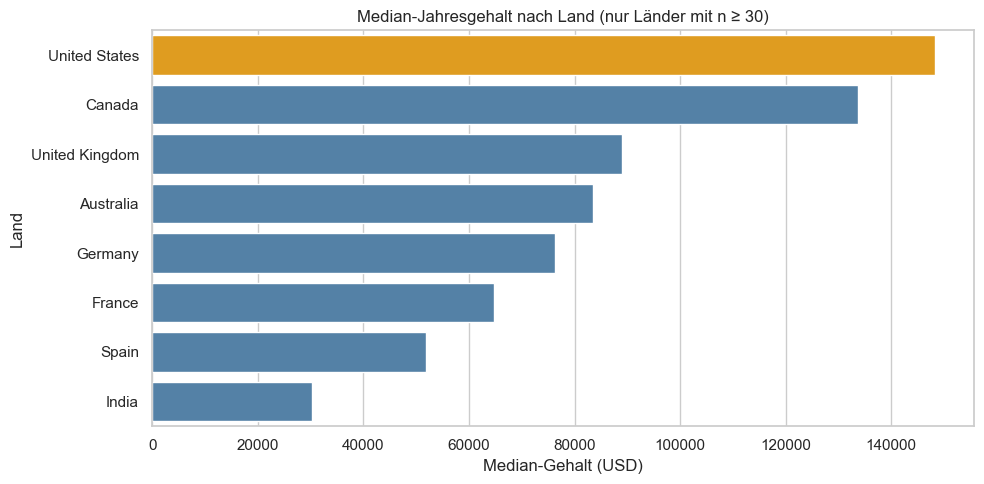

In [26]:
# Top-Länder mit ≥ 30 Einträgen
country_counts = df['company_location'].value_counts()
top_countries = country_counts[country_counts >= 30].index

df_top = df[df['company_location'].isin(top_countries)]

salary_by_country = (df_top
    .groupby('company_location')['salary_in_usd']
    .agg(count='count', median='median')
    .round({'median': 0})
    .sort_values('median', ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['orange' if c == 'United States' else 'steelblue'
          for c in salary_by_country['company_location']]

sns.barplot(
    data=salary_by_country,
    x='median',
    y='company_location',
    palette=colors,
    hue='company_location',
    legend=False,
    ax=ax
)

ax.set_title('Median-Jahresgehalt nach Land (nur Länder mit n ≥ 30)')
ax.set_xlabel('Median-Gehalt (USD)')
ax.set_ylabel('Land')

plt.tight_layout()
plt.show()

### Fazit: Geografische Unterschiede

| Region        | Median (USD) | n     |
|---------------|--------------|-------|
| USA           | 148.250      | 5.354 |
| Rest der Welt | 95.000       | 485   |
| Europa        | 73.840       | 760   |

Der US-Median (~148k USD) liegt fast doppelt so hoch wie der europäische (~74k USD).
Innerhalb der Top-Länder (n ≥ 30): **Kanada** (~134k) liegt nahe an den USA,
**UK** (~89k) und **Australien** (~84k) im oberen Bereich,
**Deutschland** (~76k), **Frankreich** (~65k), **Spanien** (~52k) und
**Indien** (~30k) zeigen zunehmende Distanz zum US-Niveau.

**Methodischer Hinweis:** Der Vergleich ist nicht kaufkraftbereinigt (PPP).
Ein Senior-Gehalt von 76k USD in Deutschland entspricht real einem anderen Lebensstandard
als 148k USD in den USA – direkte Vergleiche sollten diesen Kontext berücksichtigen.

## 8. Unternehmensgröße als Faktor

In [27]:
salary_by_company = (df
                  .groupby("company_size")["salary_in_usd"]
                  .agg(mean = "mean", median = "median", count = "count")
                  .round({"mean" : 2, "median" : 2})
                  .reset_index())
salary_by_company

,company_size,mean,median,count
0,Large,120638.40,106000.0,569
1,Medium,149659.39,141562.5,5860
2,Small,87687.46,74500.0,170


/var/folders/_d/4llk731n547f811mb_kz1m2h0000gn/T/ipykernel_9185/4290743443.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


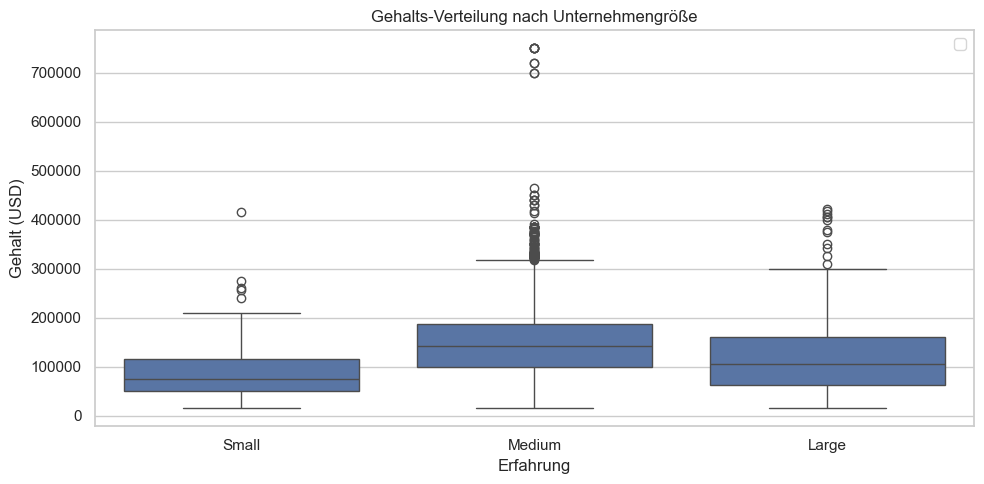

In [28]:
fig, ax = plt.subplots(figsize = (10,5))

sns.boxplot(data=df, x="company_size",y="salary_in_usd",order=["Small", "Medium", "Large"])

ax.set_title("Gehalts-Verteilung nach Unternehmensgröße")
ax.set_xlabel("Unternehmensgröße")
ax.set_ylabel("Gehalt (USD)")


plt.tight_layout()

plt.show()

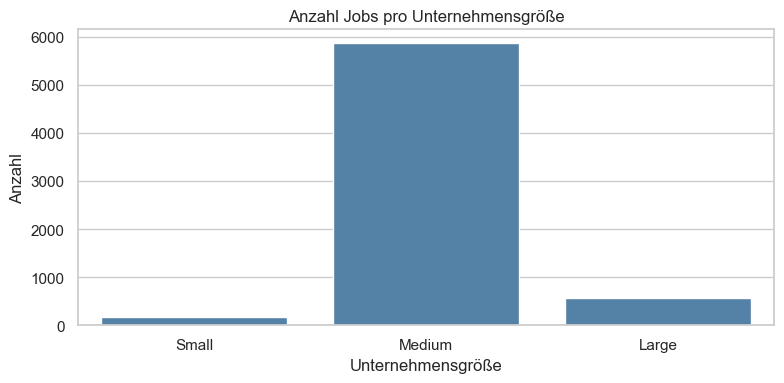

In [29]:
fig, ax = plt.subplots(figsize=(8,4))

sns.barplot(data=salary_by_company,x = "company_size", y = "count", ax=ax, color="steelblue",order=["Small", "Medium", "Large"])

ax.set_title("Anzahl Jobs pro Unternehmensgröße")
ax.set_xlabel("Unternehmensgröße")
ax.set_ylabel("Anzahl")
plt.tight_layout()
plt.show()

**Hinweis zur Interpretation:** Der Datensatz ist stark auf mittelgroße Unternehmen konzentriert 
(~89% der Einträge, n≈5.860 vs. Large n≈569 vs. Small n≈170). 
Da die Daten auf freiwilliger Selbstangabe basieren (ai-jobs.net), besteht ein **Self-Selection Bias**: 
Mittelgroße Tech-Unternehmen und Startups sind auf solchen Plattformen überrepräsentiert, 
während Großkonzerne (z.B. durch NDAs) seltener vertreten sind. 
Die Gehaltsunterschiede zwischen den Unternehmensgrößen sollten daher nicht als strukturelles Ergebnis interpretiert werden, 
sondern als Artefakt der Datenerhebung.

## 9. Fazit & Key Findings

Diese EDA untersucht Gehaltsdaten aus dem Data-Science- und ML-Bereich (2020–2024, n≈6.600 nach Bereinigung).
Die zentralen Erkenntnisse:

---

### 1. Gehaltswachstum 2020–2024
Der Median-Jahresverdienst stieg von ~80k USD (2020) auf ~143k USD (2023) – ein Zuwachs von knapp 80% in drei Jahren.
2024 zeigt einen leichten Rückgang (~138k), was auf Marktkorrektur oder geringere Sample Size (n=571) zurückzuführen sein könnte.

### 2. Erfahrungslevel ist der stärkste Gehaltstreiber
| Level           | Median (USD) |
|-----------------|--------------|
| Entry-level     | 75.000       |
| Mid-level       | 106.500      |
| Senior-level    | 153.600      |
| Executive-level | 184.560      |

Entry-Level verdient weniger als halb so viel wie Senior-Level. Kein anderer Faktor
in dieser Analyse zeigt eine vergleichbar starke Differenzierung.

### 3. Job-Titel: ML/AI-Rollen an der Spitze
Director of Data Science (~203k), Applied Scientist (~191k) und ML Engineer (~189k)
führen das Ranking an. BI- und Analyst-Rollen (Data Specialist, Research Analyst: ~85k)
bilden das untere Ende – trotz ähnlicher Datenkompetenz.
Analyse auf 24 Titel mit ≥ 30 Einträgen beschränkt (von 132 gesamt).

### 4. Remote-Arbeit zahlt sich finanziell kaum aus
| Work Model | Median (USD) | n     |
|------------|--------------|-------|
| On-site    | 142.200      | 3.808 |
| Remote     | 136.850      | 2.531 |
| Hybrid     | 69.133       | 213   |

Unterschied On-site vs. Remote: ~3,8% – nicht signifikant.
Hybrid ist mit n=213 zu schwach vertreten für belastbare Aussagen.

### 5. US-Markt dominiert – sowohl im Datensatz als auch beim Gehalt
| Region        | Median (USD) | n     |
|---------------|--------------|-------|
| USA           | 148.250      | 5.354 |
| Rest der Welt | 95.000       | 485   |
| Europa        | 73.840       | 760   |

~80% der Daten kommen aus den USA. Der US-Median liegt fast doppelt so hoch wie der europäische.
Kein kaufkraftbereinigter Vergleich (PPP) – direkte Zahlenvergleiche haben eingeschränkte Aussagekraft.

### 6. Unternehmensgröße: Datenlage eingeschränkt
~89% der Einträge stammen aus mittelgroßen Unternehmen (Self-Selection Bias auf ai-jobs.net).
Ein belastbarer Größenvergleich ist auf Basis dieses Datensatzes nicht möglich.

---

### Methodische Grenzen
- **Self-Reporting Bias:** Daten auf ai-jobs.net basieren auf freiwilliger Selbstangabe
- **US-Overrepresentation:** 80% der Daten aus einem Markt verzerrt alle Gesamtstatistiken
- **Keine PPP-Bereinigung:** Gehaltsvergleiche zwischen Ländern sind ohne Kaufkraftanpassung irreführend
- **Kleine Sample Sizes:** Frühe Jahre (2020: n=75), Hybrid-Modell (n=213), Executive-Level (n=254) –
  Trends für diese Gruppen sind statistisch weniger stabil